# Experiment 01: GPR B-scan Classification Baseline

**Goal**: Can a CNN distinguish intact ground from cavities and utilities in GPR radargrams?

This is the simplest framing of the task. 3-class classification on augmented 224x224 grayscale images, split by original image ID to prevent leakage.

See `docs/experiment_01_baseline.md` for the full experiment spec.

**Baselines**:
- A: Simple 4-block CNN (lower bound)
- B: Fine-tuned ResNet18 (transfer learning upper bound)

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed" / "classification"
FIGURES = ROOT / "results" / "figures"
MODELS_DIR = ROOT / "results" / "models"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Split data at: {PROCESSED}")

CLASS_NAMES = ["cavities", "intact", "utilities"]
NUM_CLASSES = len(CLASS_NAMES)
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda
Split data at: /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/classification


## 1. Dataset and DataLoader

Load the pre-split data from `data/processed/classification/{train,val,test}/{class}/`. Verify counts match the manifest.

In [2]:
class GPRDataset(Dataset):
    """Simple image classification dataset for GPR B-scans."""

    def __init__(self, root_dir: Path, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

        for cls_name in CLASS_NAMES:
            cls_dir = root_dir / cls_name
            if not cls_dir.exists():
                print(f"  WARNING: {cls_dir} not found")
                continue
            for img_path in sorted(cls_dir.iterdir()):
                if img_path.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    self.samples.append((img_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")  # force grayscale
        if self.transform:
            img = self.transform(img)
        return img, label


# Transforms: resize to 224x224 (some images aren't standard), normalize to [0, 1]
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # scales [0, 255] -> [0.0, 1.0]
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Build datasets
train_ds = GPRDataset(PROCESSED / "train", transform=train_transform)
val_ds = GPRDataset(PROCESSED / "val", transform=val_transform)
test_ds = GPRDataset(PROCESSED / "test", transform=val_transform)

print(f"Train: {len(train_ds)} images")
print(f"Val:   {len(val_ds)} images")
print(f"Test:  {len(test_ds)} images")

# Verify class distribution
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    labels = [s[1] for s in ds.samples]
    counts = Counter(labels)
    print(f"  {name}: {dict((CLASS_NAMES[k], v) for k, v in sorted(counts.items()))}")

Train: 1521 images
Val:   329 images
Test:  389 images
  train: {'cavities': 385, 'intact': 590, 'utilities': 546}
  val: {'cavities': 77, 'intact': 138, 'utilities': 114}
  test: {'cavities': 91, 'intact': 172, 'utilities': 126}


In [3]:
# Compute class weights for weighted cross-entropy (inverse frequency)
train_labels = [s[1] for s in train_ds.samples]
label_counts = Counter(train_labels)
total = len(train_labels)
class_weights = torch.tensor(
    [total / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)
print(f"Class weights: {dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3)))}")

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check: visualize a batch
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}, labels: {labels[:8].tolist()}")
print(f"Pixel range: [{imgs.min():.3f}, {imgs.max():.3f}]")

Class weights: {'cavities': np.float32(1.317), 'intact': np.float32(0.859), 'utilities': np.float32(0.929)}


Batch shape: torch.Size([32, 1, 224, 224]), labels: [1, 1, 2, 2, 2, 1, 2, 2]
Pixel range: [0.000, 1.000]


## 2. Model Definitions

### Baseline A: Simple CNN
4 conv blocks, global average pool, FC head. Nothing fancy. This tells us whether the task is learnable with minimal architecture.

### Baseline B: ResNet18 (pretrained)
Standard transfer learning. Modify the input conv for 1 channel and swap the final FC for 3 classes.

In [4]:
class SimpleCNN(nn.Module):
    """4-block CNN for GPR classification."""

    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x224x224 -> 32x112x112
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 32x112x112 -> 64x56x56
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 64x56x56 -> 128x28x28
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4: 128x28x28 -> 256x14x14
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_resnet18(num_classes=3):
    """ResNet18 with 1-channel input and custom head."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Average the 3-channel pretrained weights into 1 channel
    old_conv = model.conv1
    new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    with torch.no_grad():
        new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
    model.conv1 = new_conv

    # Replace final FC
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model


# Verify architectures
cnn = SimpleCNN(NUM_CLASSES)
resnet = build_resnet18(NUM_CLASSES)

dummy = torch.randn(2, 1, 224, 224)
print(f"SimpleCNN output: {cnn(dummy).shape}")
print(f"ResNet18  output: {resnet(dummy).shape}")

# Parameter counts
cnn_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
resnet_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"\nSimpleCNN params:  {cnn_params:,}")
print(f"ResNet18 params:   {resnet_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/michael-ramirez/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  6%|▌         | 2.62M/44.7M [00:00<00:04, 10.0MB/s]

 45%|████▍     | 19.9M/44.7M [00:00<00:00, 68.3MB/s]

 81%|████████  | 36.2M/44.7M [00:00<00:00, 102MB/s] 

100%|██████████| 44.7M/44.7M [00:00<00:00, 88.6MB/s]

SimpleCNN output: torch.Size([2, 3])
ResNet18  output: torch.Size([2, 3])

SimpleCNN params:  422,083
ResNet18 params:   11,171,779


## 3. Training Loop

Standard train/val loop with early stopping. Track loss and accuracy per epoch, save best model by val accuracy.

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += imgs.size(0)

        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    return total_loss / total, correct / total, all_probs, all_labels


def train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=40, patience=7, model_name="model",
):
    """Full training loop with early stopping."""
    best_val_acc = 0.0
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    save_path = MODELS_DIR / f"{model_name}_best.pt"
    save_path.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        gap = train_acc - val_acc

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:3d}/{num_epochs}  "
                f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  "
                f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f}  "
                f"gap={gap:.3f}"
            )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val_acc: {best_val_acc:.3f}")
            break

    print(f"Training complete. Best val_acc: {best_val_acc:.3f}")
    print(f"Model saved to {save_path}")
    return history

### Train Baseline A: Simple CNN

In [6]:
cnn_model = SimpleCNN(NUM_CLASSES, dropout=0.4).to(DEVICE)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=40)

print("Training SimpleCNN...")
cnn_history = train_model(
    cnn_model, train_loader, val_loader, cnn_criterion, cnn_optimizer, cnn_scheduler,
    num_epochs=40, patience=7, model_name="simple_cnn",
)

Training SimpleCNN...


Epoch   1/40  train_loss=0.4737  train_acc=0.824  val_loss=0.3795  val_acc=0.809  gap=0.016


Epoch   5/40  train_loss=0.2076  train_acc=0.932  val_loss=0.3520  val_acc=0.857  gap=0.075


Epoch  10/40  train_loss=0.1494  train_acc=0.949  val_loss=0.1841  val_acc=0.960  gap=-0.011


Epoch  15/40  train_loss=0.1237  train_acc=0.958  val_loss=0.2476  val_acc=0.960  gap=-0.003


Early stopping at epoch 19. Best val_acc: 0.967
Training complete. Best val_acc: 0.967
Model saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/results/models/simple_cnn_best.pt


### Train Baseline B: ResNet18 (pretrained)

Freeze backbone for first 5 epochs, then unfreeze everything.

In [7]:
resnet_model = build_resnet18(NUM_CLASSES).to(DEVICE)
resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)

# Phase 1: frozen backbone (5 epochs)
for param in resnet_model.parameters():
    param.requires_grad = False
for param in resnet_model.fc.parameters():
    param.requires_grad = True

resnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-3, weight_decay=1e-4,
)

print("ResNet18 Phase 1: frozen backbone (5 epochs)...")
resnet_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(5):
    tl, ta = train_one_epoch(resnet_model, train_loader, resnet_criterion, resnet_optimizer)
    vl, va, _, _ = evaluate(resnet_model, val_loader, resnet_criterion)
    resnet_history["train_loss"].append(tl)
    resnet_history["train_acc"].append(ta)
    resnet_history["val_loss"].append(vl)
    resnet_history["val_acc"].append(va)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/5  train_acc={ta:.3f}  val_acc={va:.3f}")

# Phase 2: unfreeze everything, lower LR
print("\nResNet18 Phase 2: unfrozen (35 epochs)...")
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-4, weight_decay=1e-4)
resnet_scheduler = optim.lr_scheduler.CosineAnnealingLR(resnet_optimizer, T_max=35)

phase2_history = train_model(
    resnet_model, train_loader, val_loader, resnet_criterion, resnet_optimizer, resnet_scheduler,
    num_epochs=35, patience=7, model_name="resnet18",
)

# Merge histories
for key in resnet_history:
    resnet_history[key].extend(phase2_history[key])

ResNet18 Phase 1: frozen backbone (5 epochs)...


  Epoch 1/5  train_acc=0.735  val_acc=0.675


  Epoch 5/5  train_acc=0.926  val_acc=0.976

ResNet18 Phase 2: unfrozen (35 epochs)...


Epoch   1/35  train_loss=0.0965  train_acc=0.970  val_loss=0.0142  val_acc=0.997  gap=-0.027


Epoch   5/35  train_loss=0.0056  train_acc=0.999  val_loss=0.0056  val_acc=0.997  gap=0.002


Epoch  10/35  train_loss=0.0009  train_acc=1.000  val_loss=0.0036  val_acc=1.000  gap=0.000
Early stopping at epoch 10. Best val_acc: 1.000
Training complete. Best val_acc: 1.000
Model saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/results/models/resnet18_best.pt


## 4. Training Curves

Compare convergence behavior between the two baselines. Watch for overfitting (large train-val gap).

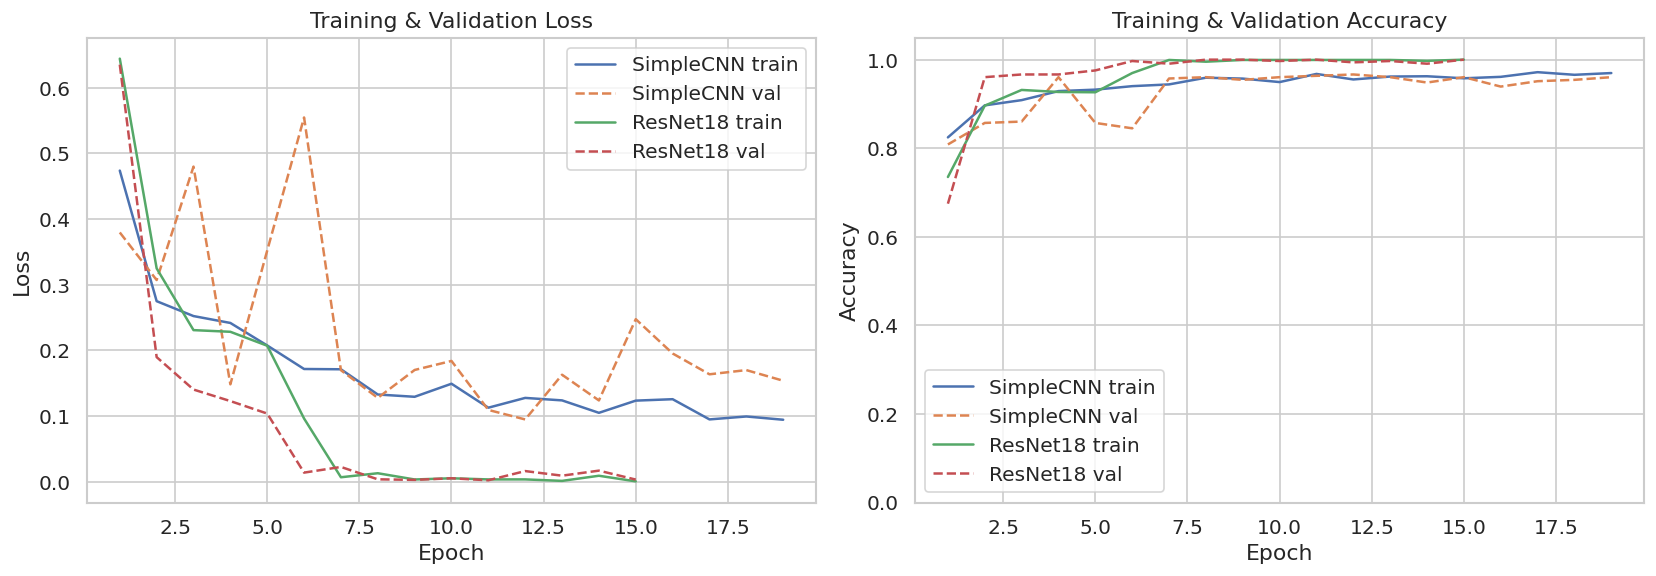

In [8]:
def plot_training_curves(histories, names, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, name in zip(histories, names):
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs, hist["train_loss"], label=f"{name} train", linestyle="-")
        axes[0].plot(epochs, hist["val_loss"], label=f"{name} val", linestyle="--")

        axes[1].plot(epochs, hist["train_acc"], label=f"{name} train", linestyle="-")
        axes[1].plot(epochs, hist["val_acc"], label=f"{name} val", linestyle="--")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training & Validation Accuracy")
    axes[1].legend()
    axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    if save_name:
        plt.savefig(FIGURES / save_name, bbox_inches="tight")
    plt.show()

plot_training_curves(
    [cnn_history, resnet_history],
    ["SimpleCNN", "ResNet18"],
    save_name="baseline_training_curves.png",
)

## 5. Test Set Evaluation

Load best checkpoints and evaluate on the held-out test set. This is the number that matters.


  SimpleCNN -- TEST SET RESULTS
  Accuracy: 0.9666
  Loss:     0.1215

              precision    recall  f1-score   support

    cavities      1.000     0.857     0.923        91
      intact      1.000     1.000     1.000       172
   utilities      0.906     1.000     0.951       126

    accuracy                          0.967       389
   macro avg      0.969     0.952     0.958       389
weighted avg      0.970     0.967     0.966       389



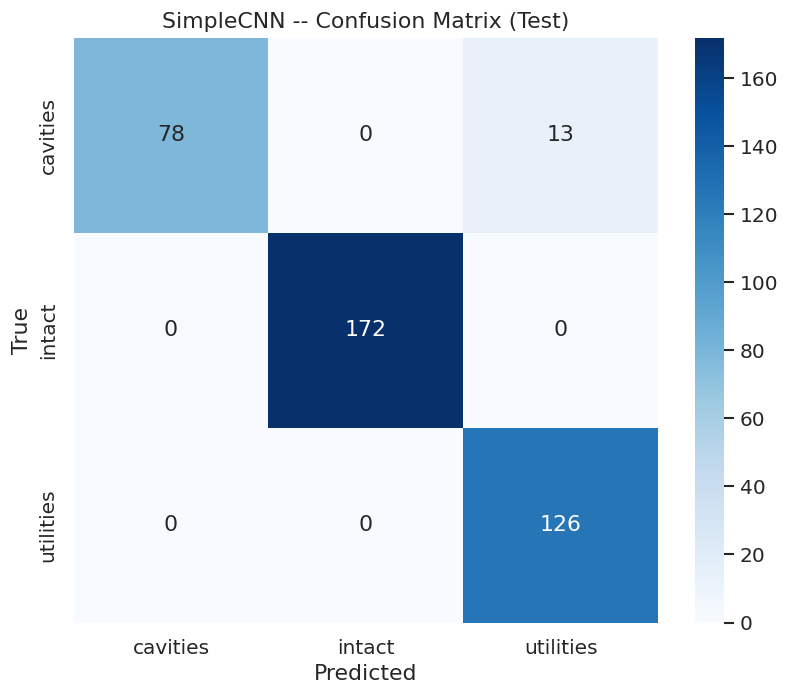

  ROC-AUC (macro, one-vs-rest): 0.9946



  ResNet18 -- TEST SET RESULTS
  Accuracy: 0.9949
  Loss:     0.0135

              precision    recall  f1-score   support

    cavities      1.000     0.978     0.989        91
      intact      1.000     1.000     1.000       172
   utilities      0.984     1.000     0.992       126

    accuracy                          0.995       389
   macro avg      0.995     0.993     0.994       389
weighted avg      0.995     0.995     0.995       389



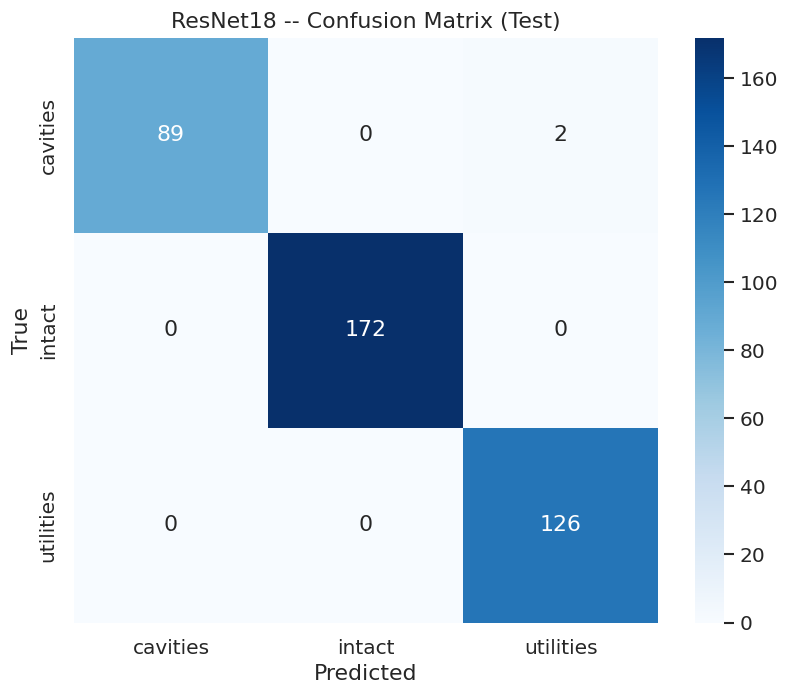

  ROC-AUC (macro, one-vs-rest): 1.0000


In [9]:
def full_evaluation(model, model_name, loader, criterion):
    """Run full evaluation and print all metrics."""
    test_loss, test_acc, probs, labels = evaluate(model, loader, criterion)

    preds = probs.argmax(axis=1)

    print(f"\n{'='*60}")
    print(f"  {model_name} -- TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Loss:     {test_loss:.4f}")
    print()
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name} -- Confusion Matrix (Test)")
    plt.tight_layout()
    plt.savefig(FIGURES / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", bbox_inches="tight")
    plt.show()

    # ROC-AUC (one-vs-rest)
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        auc = roc_auc_score(labels_bin, probs, multi_class="ovr", average="macro")
        print(f"  ROC-AUC (macro, one-vs-rest): {auc:.4f}")
    except Exception as e:
        print(f"  ROC-AUC computation failed: {e}")

    return {"accuracy": test_acc, "loss": test_loss, "preds": preds, "probs": probs, "labels": labels}


# Load best SimpleCNN
cnn_eval = SimpleCNN(NUM_CLASSES).to(DEVICE)
cnn_eval.load_state_dict(torch.load(MODELS_DIR / "simple_cnn_best.pt", map_location=DEVICE, weights_only=True))
cnn_criterion_eval = nn.CrossEntropyLoss(weight=class_weights)
cnn_results = full_evaluation(cnn_eval, "SimpleCNN", test_loader, cnn_criterion_eval)

# Load best ResNet18
resnet_eval = build_resnet18(NUM_CLASSES).to(DEVICE)
resnet_eval.load_state_dict(torch.load(MODELS_DIR / "resnet18_best.pt", map_location=DEVICE, weights_only=True))
resnet_criterion_eval = nn.CrossEntropyLoss(weight=class_weights)
resnet_results = full_evaluation(resnet_eval, "ResNet18", test_loader, resnet_criterion_eval)

## 6. Results Comparison

In [10]:
# Summary comparison table
summary = pd.DataFrame({
    "Model": ["SimpleCNN", "ResNet18"],
    "Test Accuracy": [cnn_results["accuracy"], resnet_results["accuracy"]],
    "Test Loss": [cnn_results["loss"], resnet_results["loss"]],
    "Epochs Trained": [len(cnn_history["train_loss"]), len(resnet_history["train_loss"])],
    "Final Train-Val Gap": [
        cnn_history["train_acc"][-1] - cnn_history["val_acc"][-1],
        resnet_history["train_acc"][-1] - resnet_history["val_acc"][-1],
    ],
})
print(summary.to_string(index=False))

# Save to CSV
summary.to_csv(ROOT / "results" / "tables" / "baseline_results.csv", index=False)
print(f"\nSaved to results/tables/baseline_results.csv")

    Model  Test Accuracy  Test Loss  Epochs Trained  Final Train-Val Gap
SimpleCNN       0.966581    0.12155              19              0.00927
 ResNet18       0.994859    0.01355              15              0.00000

Saved to results/tables/baseline_results.csv


## 7. Error Analysis

Look at what the model gets wrong. Misclassified samples can reveal dataset issues, model weaknesses, or genuinely ambiguous cases.

ResNet18: 2 misclassified out of 389 test images


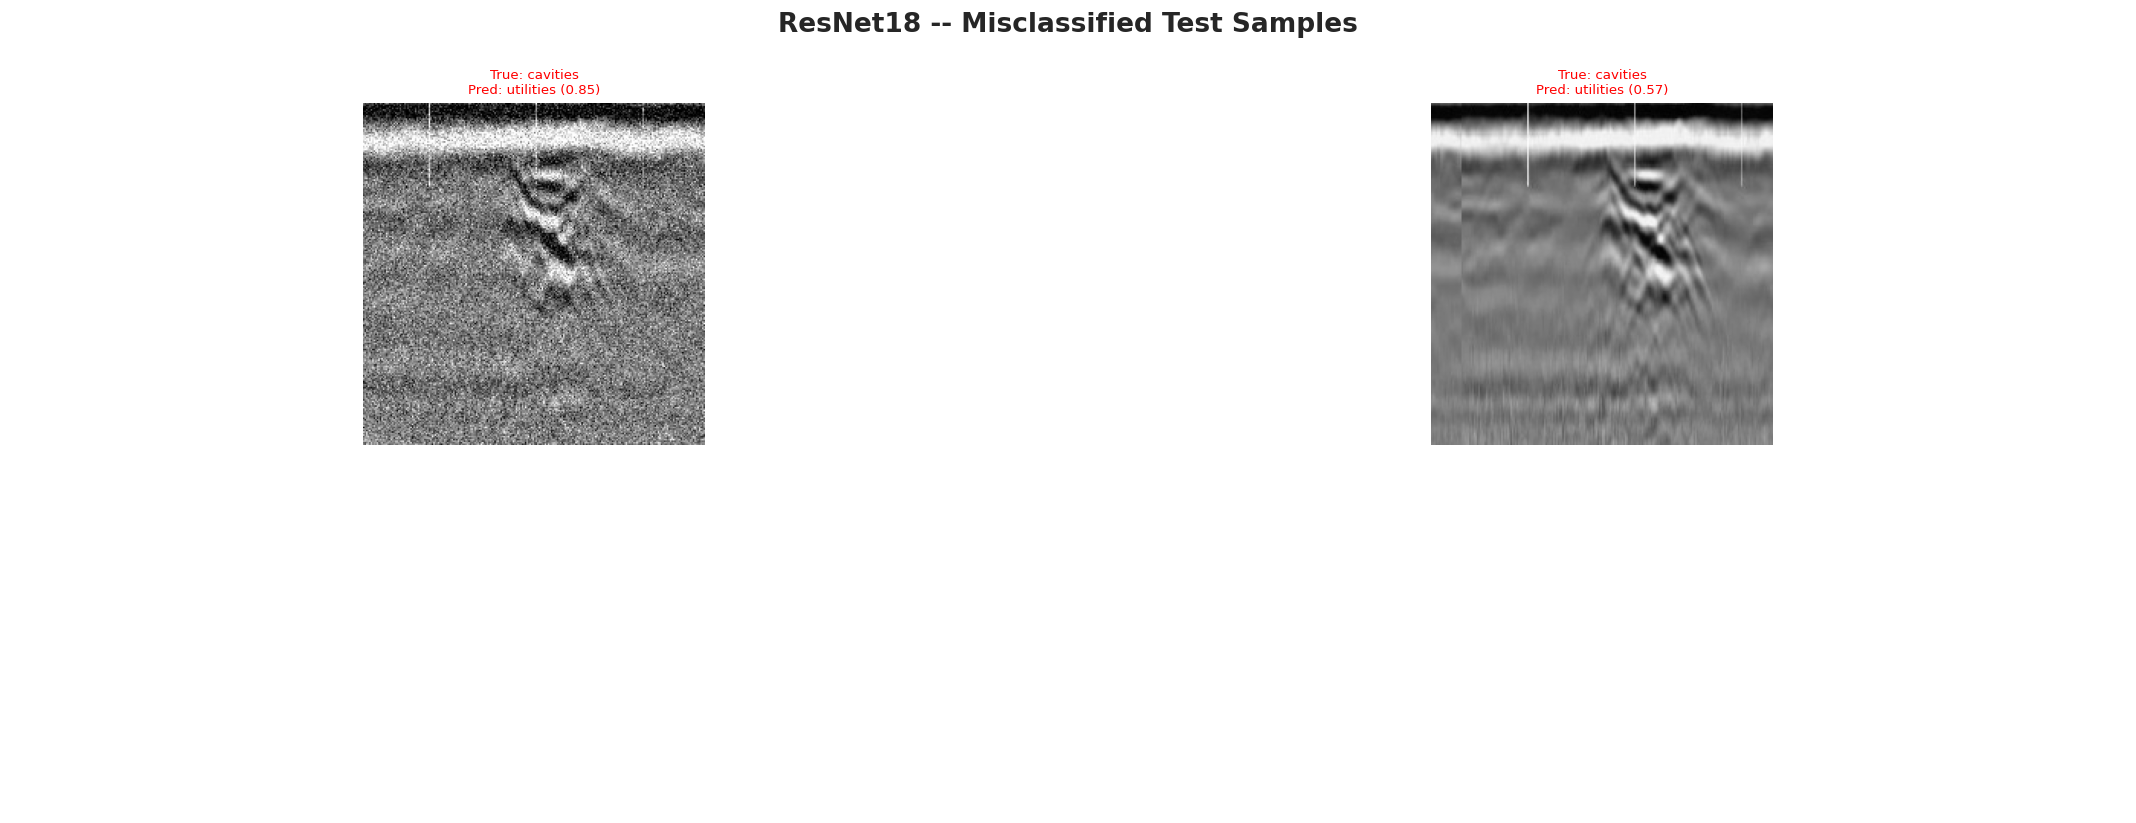

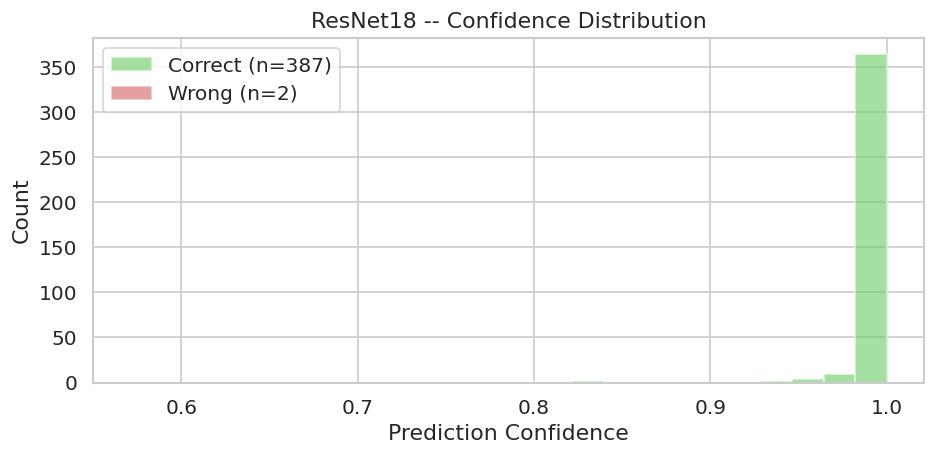

In [11]:
# Show misclassified examples from the best model
best_results = resnet_results  # or cnn_results, whichever is better
best_name = "ResNet18"

misclassified_idx = np.where(best_results["preds"] != best_results["labels"])[0]
print(f"{best_name}: {len(misclassified_idx)} misclassified out of {len(best_results['labels'])} test images")

if len(misclassified_idx) > 0:
    n_show = min(12, len(misclassified_idx))
    fig, axes = plt.subplots(2, min(6, n_show), figsize=(18, 7))
    axes = np.atleast_2d(axes)

    for i in range(n_show):
        ax = axes[i // 6, i % 6]
        idx = misclassified_idx[i]
        img_path, true_label = test_ds.samples[idx]
        img = np.array(Image.open(img_path).convert("L"))
        pred_label = int(best_results["preds"][idx])
        confidence = best_results["probs"][idx][pred_label]

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence:.2f})",
            fontsize=8, color="red",
        )
        ax.axis("off")

    for i in range(n_show, axes.size):
        axes.flat[i].axis("off")

    fig.suptitle(f"{best_name} -- Misclassified Test Samples", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES / "misclassified_examples.png", bbox_inches="tight")
    plt.show()

    # Confidence distribution for correct vs incorrect
    correct_mask = best_results["preds"] == best_results["labels"]
    correct_conf = best_results["probs"][correct_mask].max(axis=1)
    wrong_conf = best_results["probs"][~correct_mask].max(axis=1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(correct_conf, bins=20, alpha=0.6, label=f"Correct (n={correct_mask.sum()})", color="#6ACC65")
    if len(wrong_conf) > 0:
        ax.hist(wrong_conf, bins=20, alpha=0.6, label=f"Wrong (n={len(wrong_conf)})", color="#D65F5F")
    ax.set_xlabel("Prediction Confidence")
    ax.set_ylabel("Count")
    ax.set_title(f"{best_name} -- Confidence Distribution")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / "confidence_distribution.png", bbox_inches="tight")
    plt.show()
else:
    print("No misclassified samples. Suspicious -- check for leakage.")

## 8. Interpretation and Next Steps

This section is meant to be filled in after running the notebook. Key questions to answer:

1. **Did both models beat the 70% minimum bar?** If yes, the task is learnable with this data.
2. **How big is the train-val gap?** Large gap = overfitting. Expected with ~285 unique scenes.
3. **Which class is hardest?** Check per-class recall. Cavities might be confused with intact (both have relatively low texture compared to utilities).
4. **Did the ResNet actually help over the simple CNN?** If the simple CNN is already at 90%+, the task might be too easy for this dataset.
5. **Are the errors sensible?** If the model confuses cavities with utilities, that's physically reasonable (both are subsurface anomalies). If it confuses intact with utilities, something is off.

### Where to go from here

Based on results:
- If accuracy is very high (>95%): suspect leakage or trivially separable data. Check with Grad-CAM.
- If accuracy is moderate (70-90%): good signal. Try adding augmentation, different architectures, or move to detection.
- If accuracy is low (<70%): the by-ID split might be too hard. Consider k-fold cross-validation for more stable estimates.

**Next experiments to consider:**
- Grad-CAM visualization to verify the model looks at the right parts of the B-scan
- Object detection with YOLO on the annotated cavities/utilities
- Binary framing (anomaly vs. intact) to see if collapsing classes helps
- Cross-validation with multiple seeds for confidence intervals